# Step 17 --- 2D Nonlinear Shallow Water (Wind-Driven Double Gyre)

The nonlinear rotating shallow water equations in vector-invariant form
capture the full dynamics of a wind-driven ocean basin: Sverdrup balance,
western boundary currents, and eddy shedding. Here we spin up a
double-gyre circulation driven by a zonal wind stress curl.

This tutorial demonstrates:
- The vector-invariant shallow water formulation with PV fluxes
- Wind-driven double-gyre circulation in a closed basin
- Western boundary intensification on a beta-plane

In [1]:
import diffrax as dfx
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.animation import FuncAnimation, PillowWriter

from somax.models import NonlinearShallowWater2D, NonlinearSW2DState

## Model Setup

A closed basin (wall BCs) on a beta-plane, driven by a sinusoidal
double-gyre wind stress: $\tau_x = -\tau_0 \cos(2\pi y / L_y)$.

In [2]:
nx, ny = 32, 32
Lx = Ly = 1e6
f0, beta = 1e-4, 1.6e-11
H0 = 500.0

model = NonlinearShallowWater2D.create(
    nx=nx,
    ny=ny,
    Lx=Lx,
    Ly=Ly,
    g=9.81,
    f0=f0,
    beta=beta,
    H0=H0,
    lateral_viscosity=3000.0,
    bottom_drag=1e-5,
    wind_amplitude=1e-5,
    wind_profile="doublegyre",
    bc="wall",
)

## Initial Condition: Ocean at Rest

In [3]:
h0 = jnp.full((model.grid.Ny, model.grid.Nx), H0)
u0 = jnp.zeros_like(h0)
v0 = jnp.zeros_like(h0)
state0 = NonlinearSW2DState(h=h0, u=u0, v=v0)

## Integration

We spin up the model for ~231 days. The wind injects momentum,
bottom drag and viscosity dissipate it, and a double-gyre
circulation develops with a western boundary current.

In [4]:
c = float(jnp.sqrt(9.81 * H0))
t_final = 5e6  # ~58 days (enough for spinup)
n_frames = 150
ts = jnp.linspace(0.0, t_final, n_frames)
dt = 0.2 * model.grid.dx / c

sol = model.integrate(
    state0,
    t0=0.0,
    t1=t_final,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts),
    max_steps=500_000,
)
print(f"All finite: {bool(jnp.all(jnp.isfinite(sol.ys.h)))}")

All finite: True


## Diagnostics

In [5]:
diag = model.diagnose(
    NonlinearSW2DState(h=sol.ys.h[-1], u=sol.ys.u[-1], v=sol.ys.v[-1])
)
print(f"Final KE: {float(diag.energy):.2e}")
print(f"Max |u|: {float(jnp.max(jnp.abs(sol.ys.u[-1, 2:-2, 2:-2]))):.4f} m/s")
print(f"Max |v|: {float(jnp.max(jnp.abs(sol.ys.v[-1, 2:-2, 2:-2]))):.4f} m/s")

Final KE: 1.26e+09
Max |u|: 0.8879 m/s
Max |v|: 0.8000 m/s


## Save to xarray

In [6]:
x = jnp.arange(model.grid.Nx) * model.grid.dx
y = jnp.arange(model.grid.Ny) * model.grid.dy
x_km = np.asarray(x[2:-2]) / 1e3
y_km = np.asarray(y[2:-2]) / 1e3

ds = xr.Dataset(
    {
        "h": (["time", "y", "x"], np.asarray(sol.ys.h[:, 2:-2, 2:-2])),
        "u": (["time", "y", "x"], np.asarray(sol.ys.u[:, 2:-2, 2:-2])),
        "v": (["time", "y", "x"], np.asarray(sol.ys.v[:, 2:-2, 2:-2])),
    },
    coords={
        "time": np.asarray(ts) / 86400.0,  # days
        "x": x_km,
        "y": y_km,
    },
)
ds["speed"] = np.sqrt(ds["u"] ** 2 + ds["v"] ** 2)
ds["eta"] = ds["h"] - H0  # sea surface height anomaly
ds

<xarray.Dataset> Size: 3MB
Dimensions:  (time: 150, y: 30, x: 30)
Coordinates:
  * time     (time) float32 600B 0.0 0.3884 0.7768 1.165 ... 57.09 57.48 57.87
  * y        (y) float32 120B 62.5 93.75 125.0 156.2 ... 875.0 906.2 937.5 968.8
  * x        (x) float32 120B 62.5 93.75 125.0 156.2 ... 875.0 906.2 937.5 968.8
Data variables:
    h        (time, y, x) float32 540kB 500.0 500.0 500.0 ... 499.9 499.9 500.0
    u        (time, y, x) float32 540kB 0.0 0.0 0.0 ... -0.308 -0.2002 -0.04183
    v        (time, y, x) float32 540kB 0.0 0.0 0.0 0.0 ... 0.0857 0.1304 0.1
    speed    (time, y, x) float32 540kB 0.0 0.0 0.0 0.0 ... 0.3197 0.2389 0.1084
    eta      (time, y, x) float32 540kB 0.0 0.0 0.0 ... -0.1273 -0.08905 -0.0484

## Compute Vorticity at Each Snapshot

In [7]:
from finitevolx import Difference2D

diff = Difference2D(grid=model.grid)
zeta_all = []
for i in range(n_frames):
    zeta_i = diff.curl(sol.ys.u[i], sol.ys.v[i])
    zeta_all.append(np.asarray(zeta_i[2:-2, 2:-2]))
ds["vorticity"] = (["time", "y", "x"], np.stack(zeta_all))

## Create GIF: Height, Speed, Vorticity

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Colour ranges from final frame
eta_max = float(np.percentile(np.abs(ds["eta"].values[-1]), 98))
if eta_max < 1e-6:
    eta_max = 0.1
spd_max = float(np.percentile(ds["speed"].values[-1], 98))
if spd_max < 1e-6:
    spd_max = 0.1
zeta_max = float(np.percentile(np.abs(ds["vorticity"].values[-1]), 98))
if zeta_max < 1e-12:
    zeta_max = 1e-6

im0 = axes[0].pcolormesh(
    ds.x,
    ds.y,
    ds["eta"].isel(time=0),
    cmap="RdBu_r",
    vmin=-eta_max,
    vmax=eta_max,
    shading="auto",
)
im1 = axes[1].pcolormesh(
    ds.x,
    ds.y,
    ds["speed"].isel(time=0),
    cmap="inferno",
    vmin=0,
    vmax=spd_max,
    shading="auto",
)
im2 = axes[2].pcolormesh(
    ds.x,
    ds.y,
    ds["vorticity"].isel(time=0),
    cmap="RdBu_r",
    vmin=-zeta_max,
    vmax=zeta_max,
    shading="auto",
)
plt.colorbar(im0, ax=axes[0], label="SSH (m)")
plt.colorbar(im1, ax=axes[1], label="|u| (m/s)")
plt.colorbar(im2, ax=axes[2], label="vorticity (1/s)")
for ax in axes:
    ax.set_xlabel("x (km)")
    ax.set_ylabel("y (km)")
    ax.set_aspect("equal")
axes[0].set_title("Sea Surface Height")
axes[1].set_title("Speed")
axes[2].set_title("Relative Vorticity")
title = fig.suptitle("t = 0.0 days", fontsize=14)
plt.tight_layout()


def update(frame):
    im0.set_array(ds["eta"].isel(time=frame).values.ravel())
    im1.set_array(ds["speed"].isel(time=frame).values.ravel())
    im2.set_array(ds["vorticity"].isel(time=frame).values.ravel())
    title.set_text(f"t = {ds.time.values[frame]:.1f} days")
    return im0, im1, im2, title


anim = FuncAnimation(fig, update, frames=n_frames, interval=67, blit=True)
anim.save(
    "step17_shallow_water_2d.gif",
    writer=PillowWriter(fps=15),
    dpi=80,
)
plt.close()

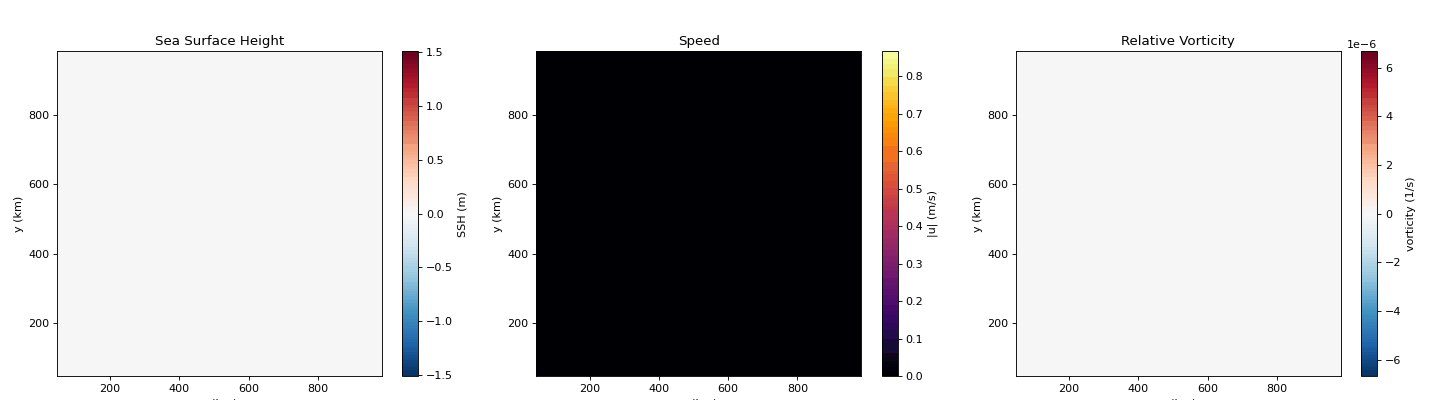

In [9]:
from IPython.display import Image, display

display(Image(filename="step17_shallow_water_2d.gif"))

## Differentiability

In [10]:
import equinox as eqx


@eqx.filter_grad
def grad_fn(m):
    sol = m.integrate(state0, t0=0.0, t1=1e5, dt=dt, max_steps=10_000)
    return jnp.sum(sol.ys.u**2)


grads = grad_fn(model)
print(f"d(loss)/d(viscosity)      = {float(grads.params.lateral_viscosity):.6e}")
print(f"d(loss)/d(wind_amplitude) = {float(grads.params.wind_amplitude):.6e}")

d(loss)/d(viscosity)      = -3.126971e-04
d(loss)/d(wind_amplitude) = 3.710990e+07


## Summary

- Wind-driven double-gyre develops western boundary intensification
- The vector-invariant form with Arakawa-Lamb PV fluxes conserves energy and enstrophy
- The beta-plane breaks north-south symmetry, producing a stronger subtropical gyre
- All parameters (viscosity, drag, wind amplitude) are differentiable

**Next:** [Step 18 --- Barotropic QG Double Gyre](step18_barotropic_qg.py)